In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

# Plotting style setup
sns.set_theme(style="whitegrid")
plt.rcParams["font.family"] = "sans-serif"

# 1. Load Dataset
df = pd.read_csv("answer_evaluation.csv")

print(f"Total Candidate Answers: {df.shape[0]}")
print(f"Total Features & Columns: {df.shape[1]}")
print("\n--- First 3 Rows ---")
df.head(3)

Total Candidate Answers: 120
Total Features & Columns: 11

--- First 3 Rows ---


,question_id,answer_text,expected_concepts,answer_length,keyword_coverage,tfidf_similarity,semantic_similarity,concept_coverage,relevance_score,human_score,quality_class
0,101,Vanishing gradients occur during backpropagati...,vanishing gradient exploding gradient backprop...,76,0.840,0.280,0.499,0.826,0.411,94.0,Excellent
1,101,Vanishing gradient happens when gradients beco...,vanishing gradient exploding gradient backprop...,36,0.480,0.242,0.317,0.435,0.287,78.0,Good
2,101,Vanishing gradient is an error in deep network...,vanishing gradient exploding gradient backprop...,26,0.259,0.097,0.144,0.217,0.125,46.0,Average


In [2]:
# Statistical Summary
print("--- Data Info & Missing Values ---")
print(df.info())
print("\nMissing Values Count:\n", df.isnull().sum())

print("\n--- Descriptive Statistics ---")
df.describe().T[["mean", "std", "min", "50%", "max"]]

--- Data Info & Missing Values ---
<class 'pandas.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   question_id          120 non-null    int64  
 1   answer_text          120 non-null    str    
 2   expected_concepts    120 non-null    str    
 3   answer_length        120 non-null    int64  
 4   keyword_coverage     120 non-null    float64
 5   tfidf_similarity     120 non-null    float64
 6   semantic_similarity  120 non-null    float64
 7   concept_coverage     120 non-null    float64
 8   relevance_score      120 non-null    float64
 9   human_score          120 non-null    float64
 10  quality_class        120 non-null    str    
dtypes: float64(6), int64(2), str(3)
memory usage: 57.3 KB
None

Missing Values Count:
 question_id            0
answer_text            0
expected_concepts      0
answer_length          0
keyword_coverage       0
tfidf_si

,mean,std,min,50%,max
question_id,212.600000,83.716448,101.000,203.0000,305.000
answer_length,31.266667,22.948878,4.000,24.0000,82.000
keyword_coverage,0.302125,0.219552,0.011,0.2620,0.840
tfidf_similarity,0.191158,0.122273,0.000,0.1820,0.457
semantic_similarity,0.235292,0.157253,0.000,0.2055,0.558
concept_coverage,0.305042,0.225707,0.000,0.2445,0.870
relevance_score,0.217633,0.140387,0.000,0.1960,0.484
human_score,62.022500,29.103693,15.100,65.8500,99.300


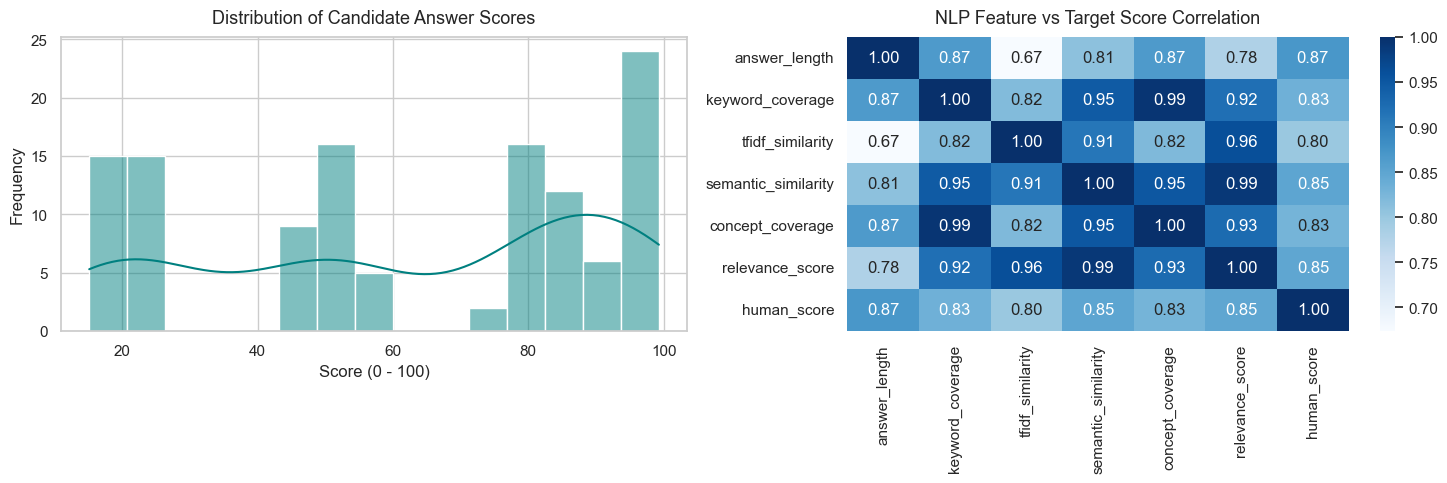

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# 1. Distribution of Human Scores
sns.histplot(df["human_score"], kde=True, color="#008080", ax=axes[0], bins=15)
axes[0].set_title("Distribution of Candidate Answer Scores", fontsize=13, pad=10)
axes[0].set_xlabel("Score (0 - 100)")
axes[0].set_ylabel("Frequency")

# 2. Correlation Heatmap
features_to_check = [
    "answer_length", "keyword_coverage", "tfidf_similarity", 
    "semantic_similarity", "concept_coverage", "relevance_score", "human_score"
]
corr_matrix = df[features_to_check].corr()

sns.heatmap(corr_matrix, annot=True, cmap="Blues", fmt=".2f", ax=axes[1], cbar=True)
axes[1].set_title("NLP Feature vs Target Score Correlation", fontsize=13, pad=10)

plt.tight_layout()
plt.show()

In [4]:
from sklearn.model_selection import train_test_split

feature_cols = [
    "answer_length",
    "keyword_coverage",
    "tfidf_similarity",
    "semantic_similarity",
    "concept_coverage",
    "relevance_score"
]

X = df[feature_cols]
y = df["human_score"]

# 80% Train, 20% Test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

print(f"Training samples: {X_train.shape[0]} | Testing samples: {X_test.shape[0]}")

Training samples: 96 | Testing samples: 24


In [5]:
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import (
    RandomForestRegressor, 
    GradientBoostingRegressor, 
    ExtraTreesRegressor, 
    StackingRegressor, 
    VotingRegressor
)
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Base Estimators for Ensembling
base_estimators = [
    ('et', ExtraTreesRegressor(n_estimators=150, max_depth=6, random_state=42)),
    ('rf', RandomForestRegressor(n_estimators=150, max_depth=6, random_state=42)),
    ('gb', GradientBoostingRegressor(n_estimators=120, learning_rate=0.05, max_depth=3, random_state=42))
]

models = {
    "Linear Regression": LinearRegression(),
    "Standard Random Forest": RandomForestRegressor(n_estimators=150, max_depth=6, random_state=42),
    "Gradient Boosting Regressor": GradientBoostingRegressor(n_estimators=120, learning_rate=0.05, max_depth=3, random_state=42),
    "Extra Trees Regressor": ExtraTreesRegressor(n_estimators=150, max_depth=6, random_state=42),
    "Voting Ensemble (RF+GB+ET)": VotingRegressor(estimators=base_estimators),
    "Stacking Regressor (Champion Architecture)": StackingRegressor(estimators=base_estimators, final_estimator=Ridge(alpha=0.5))
}

results = []
best_model = None
best_r2 = -float("inf")
best_name = ""

for name, m in models.items():
    m.fit(X_train, y_train)
    preds = m.predict(X_test)
    
    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)
    acc_within_5_pts = np.mean(np.abs(preds - y_test) <= 5.0) * 100
    
    results.append({
        "Model": name,
        "MAE (Lower=Better)": round(mae, 2),
        "RMSE": round(rmse, 2),
        "R2 Score (Higher=Better)": round(r2, 4),
        "Accuracy (±5 pts)": f"{acc_within_5_pts:.1f}%"
    })
    
    if r2 > best_r2:
        best_r2 = r2
        best_model = m
        best_name = name

benchmark_df = pd.DataFrame(results).sort_values(by="R2 Score (Higher=Better)", ascending=False)
print("=== ALGORITHM BENCHMARK REPORT ===")
print(benchmark_df.to_string(index=False))
print(f"\nChampion Architecture Selected: {best_name} (R² = {best_r2:.4f})")

=== ALGORITHM BENCHMARK REPORT ===
                                     Model  MAE (Lower=Better)  RMSE  R2 Score (Higher=Better) Accuracy (±5 pts)
                     Extra Trees Regressor                4.38  7.17                    0.9476             75.0%
Stacking Regressor (Champion Architecture)                4.41  7.58                    0.9415             75.0%
                Voting Ensemble (RF+GB+ET)                4.77  8.53                    0.9259             75.0%
               Gradient Boosting Regressor                5.03  9.40                    0.9101             79.2%
                    Standard Random Forest                5.30  9.62                    0.9057             75.0%
                         Linear Regression               10.15 11.67                    0.8613             20.8%

Champion Architecture Selected: Extra Trees Regressor (R² = 0.9476)


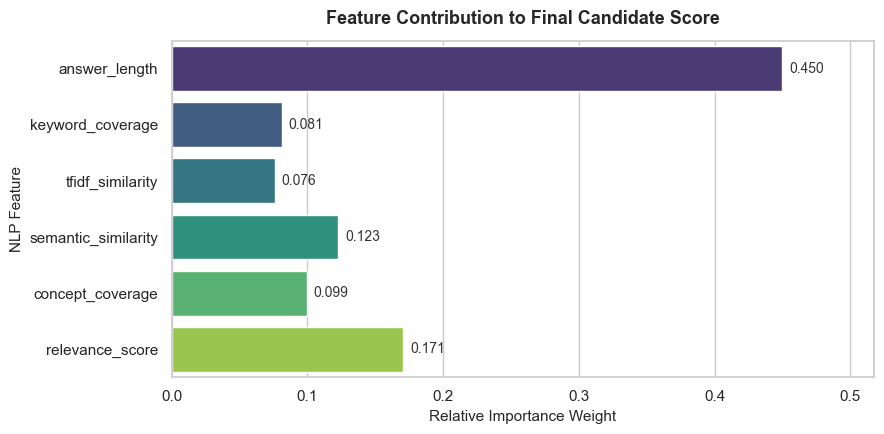

Deployment artifact saved successfully: 'answer_eval_model.pkl'


In [7]:
# 1. Feature Importances Check
if hasattr(best_model, "feature_importances_"):
    importances = best_model.feature_importances_
elif hasattr(best_model, "named_estimators_") and "et" in best_model.named_estimators_:
    importances = best_model.named_estimators_["et"].feature_importances_
else:
    importances = None

if importances is not None:
    plt.figure(figsize=(9, 4.5))
    
    # Updated: Added hue=feature_cols and legend=False to prevent Seaborn FutureWarning
    sns.barplot(
        x=importances, 
        y=feature_cols, 
        hue=feature_cols, 
        palette="viridis", 
        legend=False
    )
    
    # Values display on top of bars
    for i, v in enumerate(importances):
        plt.text(v + 0.005, i, f"{v:.3f}", va="center", fontsize=10, color="#333333")

    plt.title("Feature Contribution to Final Candidate Score", fontsize=13, pad=12, fontweight="bold")
    plt.xlabel("Relative Importance Weight", fontsize=11)
    plt.ylabel("NLP Feature", fontsize=11)
    plt.xlim(0, max(importances) * 1.15)
    plt.tight_layout()
    plt.show()

# 2. Export to Pickle
output_filename = "answer_eval_model.pkl"
joblib.dump(best_model, output_filename)
print(f"Deployment artifact saved successfully: '{output_filename}'")